In [1]:
import json
import os
from pathlib import Path

import numpy as np
import trimesh
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
from plyfile import PlyData

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# ---- Set your file paths here ----
rgb_path  = r"C:\Users\Priyam Mishra\Desktop\UTN Thesis\UTN-ThesisResearch\Webots\controllers\tb4\first3dreco\tb4_image.jpg"
mask_path = r"C:\Users\Priyam Mishra\Desktop\UTN Thesis\UTN-ThesisResearch\Webots\controllers\tb4\first3dreco\0.png"
ply_path  = r"gaussians\single\TB4_Object.ply"
intr_path = r"C:\Users\Priyam Mishra\Desktop\UTN Thesis\UTN-ThesisResearch\Webots\controllers\tb4\first3dreco\tb4_intrinsics.txt"
extr_path = r"C:\Users\Priyam Mishra\Desktop\UTN Thesis\UTN-ThesisResearch\Webots\controllers\tb4\first3dreco\tb4_extrinsic_camera.txt"
# World-space anchor
object_center_world = np.array([0.0, 0.0, 0.0], dtype=np.float32)

# Projection basis (same as your current notebook)
FORWARD = np.array([1, 0, 0], np.float32)
RIGHT   = np.array([0, 1, 0], np.float32)
UP      = np.array([0, 0,-1], np.float32)

# Search config
search_yaw = True
yaw_min, yaw_max, yaw_steps = -120.0, 120.0, 97

# Color matching config
top_k = 3000
w_mask = 1.0
w_color = 2.0

out_dir = Path("PointCloudProjectionColorTrial")
out_dir.mkdir(parents=True, exist_ok=True)
# Yaw and search options
yaw = 85.0
search_yaw = False
yaw_min = 0
yaw_max = 360
yaw_steps = 97

# Scaling options
do_scale = False
scale_iters = 6
scale_damp = 0.7
lift_mode = "min"  # "q01", "min", "none"

# Output

seed = 0
np.random.seed(0)

In [3]:
def load_rgb(path: str) -> np.ndarray:
    return np.array(Image.open(path).convert("RGB"))

def load_mask(path: str, thresh: int = 127) -> np.ndarray:
    m = np.array(Image.open(path).convert("L"))
    return (m > thresh)

def load_K(intr_path: str) -> np.ndarray:
    rows = []
    with open(intr_path, "r") as f:
        for line in f:
            line = line.strip().replace("[", "").replace("]", "")
            if not line or line.startswith("K") or line.startswith("0 0 1"):
                continue
            parts = line.split()
            if len(parts) == 3:
                rows.append([float(parts[0]), float(parts[1]), float(parts[2])])
    if len(rows) == 2:
        rows.append([0.0, 0.0, 1.0])
    K = np.array(rows, dtype=np.float32)
    if K.shape != (3, 3):
        raise ValueError(f"Parsed K has shape {K.shape}, expected (3,3)")
    return K

def load_Traw_3x4(extr_path: str) -> np.ndarray:
    rows = []
    with open(extr_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or "Extrinsic" in line:
                continue
            parts = line.split()
            if len(parts) == 4:
                rows.append([float(x) for x in parts])
    M = np.array(rows, dtype=np.float32)
    if M.shape != (3, 4):
        raise ValueError(f"Parsed extrinsic has shape {M.shape}, expected (3,4)")
    T = np.eye(4, dtype=np.float32)
    T[:3, :4] = M
    return T

def Rz(deg: float) -> np.ndarray:
    a = np.deg2rad(deg)
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s, 0],
                     [s,  c, 0],
                     [0,  0, 1]], dtype=np.float32)


def build_world_points(points_raw: np.ndarray,
                       object_center_world: np.ndarray,
                       yaw_deg: float,
                       s_xy: float = 1.0,
                       s_z: float = 1.0,
                       lift_mode: str = "q01") -> np.ndarray:
    P = points_raw.astype(np.float32)
    # Center X and Y to mean, but not Z
    P[:, 0] -= P[:, 0].mean()
    P[:, 1] -= P[:, 1].mean()
    P[:, 0] *= s_xy
    P[:, 1] *= s_xy
    P[:, 2] *= s_z
    P = P @ Rz(yaw_deg).T

    # Only shift Z so that bottom is at zero
    if lift_mode == "none":
        z0 = 0.0
    elif lift_mode == "min":
        z0 = float(P[:, 2].min())
    else:
        z0 = float(np.quantile(P[:, 2], 0.01))
    P[:, 2] -= z0

    return P + object_center_world.reshape(1, 3).astype(np.float32)


def project_with_basis(points_world: np.ndarray,
                       K: np.ndarray,
                       w2c: np.ndarray,
                       forward: np.ndarray,
                       right: np.ndarray,
                       up: np.ndarray):
    Pw = np.asarray(points_world, dtype=np.float32).reshape(-1, 3)
    N = Pw.shape[0]
    Ph = np.hstack([Pw, np.ones((N, 1), np.float32)])
    Pc = (w2c @ Ph.T).T[:, :3]

    depth = Pc @ forward
    x = Pc @ right
    y = Pc @ up

    eps = 1e-8
    depth2 = np.where(np.abs(depth) < eps, eps, depth)

    u = K[0, 0] * (x / depth2) + K[0, 2]
    v = K[1, 1] * (y / depth2) + K[1, 2]
    return u, v, depth

In [4]:
# Renderer-consistent DC mapping: rgb = clip(C0 * f_dc + 0.5, 0, 1)
C0 = 0.28209479177387814

ply = PlyData.read(ply_path)
vtx = ply["vertex"].data
names = set(vtx.dtype.names)

points = np.stack([vtx["x"], vtx["y"], vtx["z"]], axis=1).astype(np.float32)

has_dc = all(k in names for k in ["f_dc_0", "f_dc_1", "f_dc_2"])
if not has_dc:
    raise ValueError("PLY has no f_dc_* fields; cannot do color matching.")

dc = np.stack([vtx["f_dc_0"], vtx["f_dc_1"], vtx["f_dc_2"]], axis=1).astype(np.float32)
colors = np.clip(C0 * dc + 0.5, 0.0, 1.0).astype(np.float32)

print("points:", points.shape, "colors:", colors.shape, "range:", (colors.min(), colors.max()))

points: (1202688, 3) colors: (1202688, 3) range: (np.float32(0.0), np.float32(1.0))


Open3D has points: True has colors: True


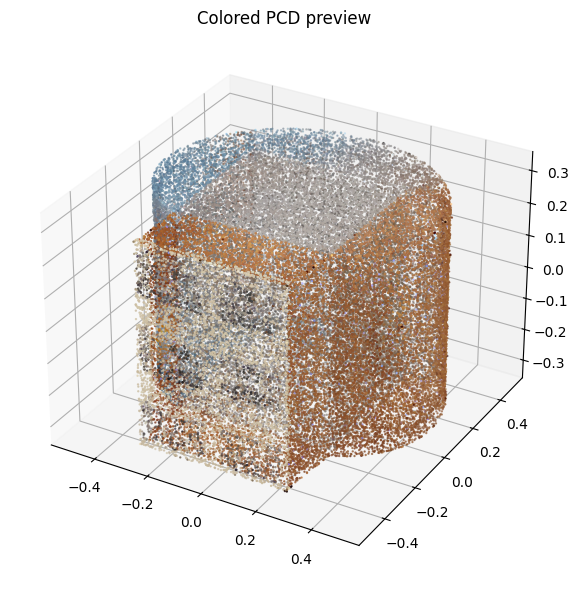

In [5]:
pcd_colors = o3d.geometry.PointCloud()
pcd_colors.points = o3d.utility.Vector3dVector(points)
pcd_colors.colors = o3d.utility.Vector3dVector(colors)

print("Open3D has points:", pcd_colors.has_points(), "has colors:", pcd_colors.has_colors())

# Quick static matplotlib preview (downsample for speed)
pts = np.asarray(pcd_colors.points)
cols = np.asarray(pcd_colors.colors)
N = pts.shape[0]
take = min(N, 50000)
idx = np.random.choice(N, take, replace=False) if N > take else np.arange(N)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pts[idx,0], pts[idx,1], pts[idx,2], c=cols[idx], s=0.5)
ax.set_title("Colored PCD preview")
plt.tight_layout()
plt.show()

In [6]:
rgb = load_rgb(rgb_path)
mask = load_mask(mask_path)
H, W = rgb.shape[:2]

K = load_K(intr_path)
T_raw = load_Traw_3x4(extr_path)

# Keep same assumption as your notebook
w2c = T_raw.astype(np.float32)

def zbuffer_visible_indices(u, v, d, W, H):
    in_front = d > 1e-3
    in_img = in_front & (u >= 0) & (u < W) & (v >= 0) & (v < H)
    idx = np.where(in_img)[0]
    if idx.size == 0:
        return np.array([], dtype=np.int64), np.array([], dtype=np.int32), np.array([], dtype=np.int32)

    uu = np.clip(np.rint(u[idx]).astype(np.int32), 0, W - 1)
    vv = np.clip(np.rint(v[idx]).astype(np.int32), 0, H - 1)
    dd = d[idx]

    pix = vv.astype(np.int64) * W + uu.astype(np.int64)

    # sort by pixel then depth (near first)
    order = np.lexsort((dd, pix))
    pix_sorted = pix[order]

    first = np.ones_like(pix_sorted, dtype=bool)
    first[1:] = pix_sorted[1:] != pix_sorted[:-1]
    keep = order[first]

    idx_vis = idx[keep]
    uu_vis = uu[keep]
    vv_vis = vv[keep]
    return idx_vis, uu_vis, vv_vis

def score_mask_overlap_visible(uu, vv, mask):
    if uu.size == 0:
        return -1e9, 0, 0
    on = mask[vv, uu] > 0
    cnt_on = int(on.sum())
    cnt_in = int(uu.size)
    score = cnt_on * 10.0 + cnt_in
    return score, cnt_on, cnt_in

def color_l1_score(rgb_img, uu, vv, point_rgb, top_k=3000):
    if uu.size == 0:
        return -1e9, 1e9, 0
    img_rgb = rgb_img[vv, uu].astype(np.float32) / 255.0
    prgb = point_rgb.astype(np.float32)
    err = np.abs(img_rgb - prgb).mean(axis=1)  # L1 per point in [0,1]

    if err.size > top_k:
        keep = np.argpartition(err, top_k)[:top_k]  # best color matches
        err = err[keep]

    mean_err = float(err.mean())
    score = -mean_err  # higher is better
    return score, mean_err, int(err.size)

visible: 168913 on-mask: 149521


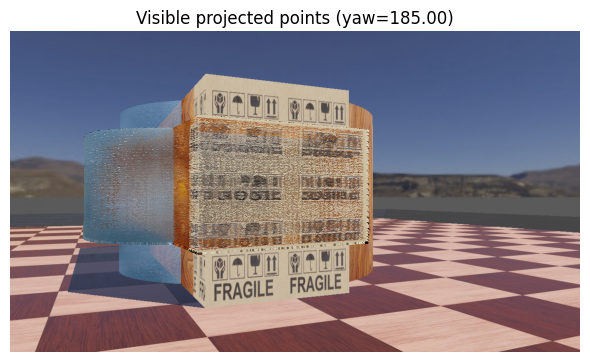

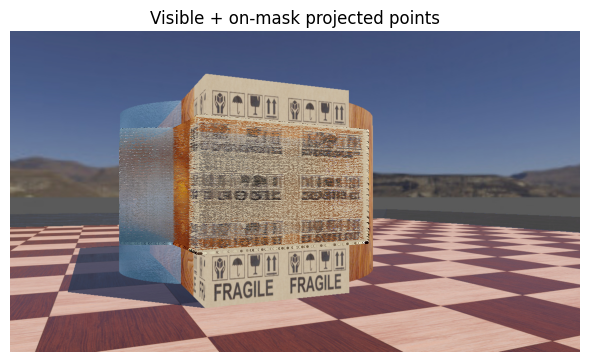

In [7]:
# Projection basis (same as your current notebook)
FORWARD = np.array([1, 0, 0], np.float32)
RIGHT   = np.array([0, -1, 0], np.float32)
UP      = np.array([0, 0, -1], np.float32)
yaw_used = 185.0
Pw = build_world_points(points, object_center_world, yaw_used, 0.9, 0.9, lift_mode="q01")
u, v, d = project_with_basis(Pw, K, w2c, FORWARD, RIGHT, UP)

idx_vis, uu_vis, vv_vis = zbuffer_visible_indices(u, v, d, W, H)
on = (mask[vv_vis, uu_vis] > 0) if uu_vis.size > 0 else np.array([], dtype=bool)

print("visible:", idx_vis.size, "on-mask:", int(on.sum()))

# 1) all visible colored points
plt.figure(figsize=(6,6))
plt.imshow(rgb)
if idx_vis.size > 0:
    plt.scatter(u[idx_vis], v[idx_vis], s=0.6, c=colors[idx_vis])
plt.title(f"Visible projected points (yaw={yaw_used:.2f})")
plt.axis("off")
plt.tight_layout()
plt.savefig(out_dir / "overlay_rgb_color_visible.png", dpi=200)
plt.show()

# 2) only visible + on-mask points
plt.figure(figsize=(6,6))
plt.imshow(rgb)
if idx_vis.size > 0 and on.size > 0:
    idx_on = idx_vis[on]
    plt.scatter(u[idx_on], v[idx_on], s=0.8, c=colors[idx_on])
plt.title("Visible + on-mask projected points")
plt.axis("off")
plt.tight_layout()
plt.savefig(out_dir / "overlay_rgb_color_onmask.png", dpi=200)
plt.show()

In [8]:
# Add this function to your notebook (anywhere after imports)
def depth_probability(depth, yaw, invert_range=(170, 190)):
    """
    Assigns probability based on depth and yaw.
    - For yaw in invert_range, farther points get higher probability.
    - Otherwise, closer points get higher probability.
    """
    d = np.asarray(depth)
    d_min, d_max = np.percentile(d, [1, 99])  # robust min/max
    d_norm = (d - d_min) / (d_max - d_min + 1e-8)
    if invert_range[0] <= yaw <= invert_range[1]:
        prob = 1.0 - d_norm  # farther = higher
    else:
        prob = 1.0   # closer = higher
    prob = np.clip(prob, 0, 1)
    return prob

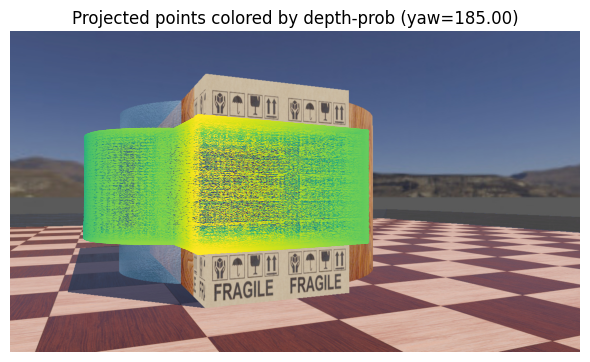

In [9]:
# ...existing code...
prob = depth_probability(d, yaw_used)
# Now prob[idx_vis] gives the probability for each visible point
# Example: color points by probability
plt.figure(figsize=(6,6))
plt.imshow(rgb)
if idx_vis.size > 0:
    plt.scatter(u[idx_vis], v[idx_vis], s=0.8, c=prob[idx_vis], cmap='viridis')
plt.title(f"Projected points colored by depth-prob (yaw={yaw_used:.2f})")
plt.axis("off")
plt.tight_layout()
plt.show()
# ...existing code...

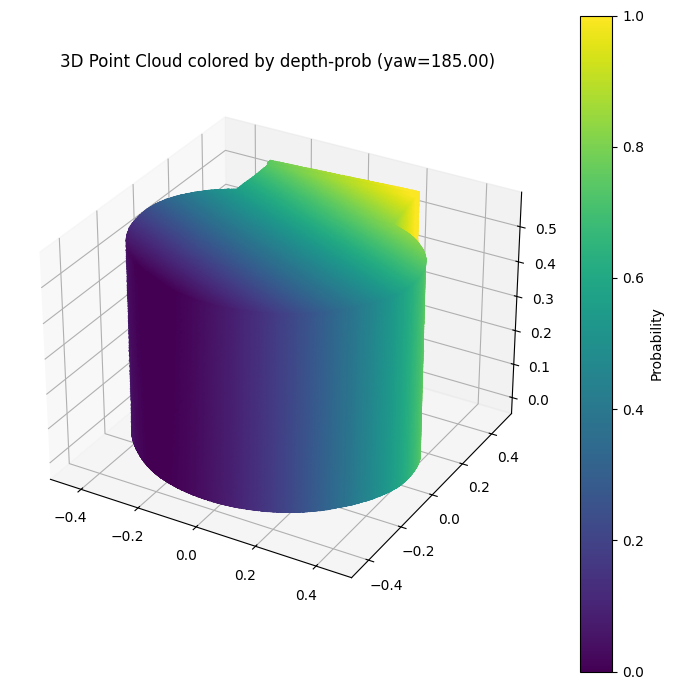

In [10]:
# ...existing code...

# Calculate probability for all points based on depth and yaw
prob = depth_probability(d, yaw_used)

# Plot the 3D point cloud colored by probability
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(Pw[:,0], Pw[:,1], Pw[:,2], c=prob, cmap='viridis', s=1)
plt.title(f"3D Point Cloud colored by depth-prob (yaw={yaw_used:.2f})")
plt.colorbar(sc, label='Probability')
plt.tight_layout()
plt.show()

# ...existing code...

In [11]:
import numpy as np
from scipy.spatial.transform import Rotation as R

# 1. Camera center in world
cam_to_world = np.linalg.inv(T_raw)
cam_center = cam_to_world[:3, 3]

# 2. Highest-probability point
max_idx = np.argmax(prob)
target_point = Pw[max_idx]

# 3. Directions
cam_forward = cam_to_world[:3, 2]
cam_forward /= np.linalg.norm(cam_forward)
dir_to_target = target_point - cam_center
dir_to_target /= np.linalg.norm(dir_to_target)

# 4. Rotation to align
rot, _ = R.align_vectors([dir_to_target], [cam_forward])
rot_matrix = rot.as_matrix()

# rot_matrix now rotates cam_forward to point at the highest-probability point

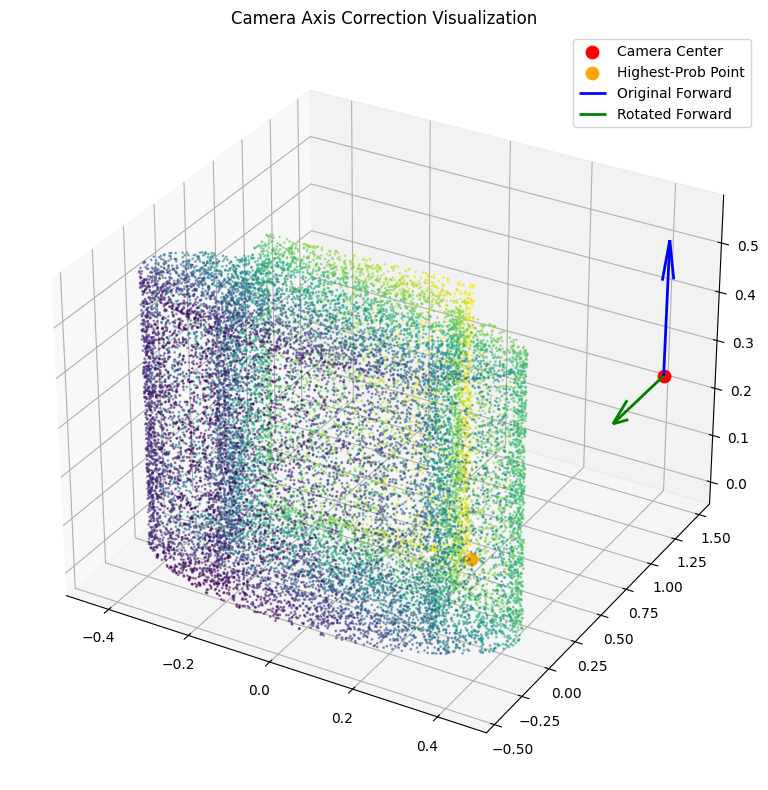

In [12]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Plot point cloud (downsample for speed)
N = Pw.shape[0]
take = min(N, 20000)
idx = np.random.choice(N, take, replace=False) if N > take else np.arange(N)
ax.scatter(Pw[idx,0], Pw[idx,1], Pw[idx,2], c=prob[idx], cmap='viridis', s=1, alpha=0.5)

# Plot camera center
ax.scatter(*cam_center, color='red', s=80, label='Camera Center')

# Plot highest-probability point
ax.scatter(*target_point, color='orange', s=80, label='Highest-Prob Point')

# Plot original camera forward axis
scale = 0.2 * np.linalg.norm(Pw.max(axis=0) - Pw.min(axis=0))
ax.quiver(*cam_center, *(cam_forward*scale), color='blue', linewidth=2, label='Original Forward')

# Plot rotated axis (should point to target)
rotated_forward = rot_matrix @ cam_forward
ax.quiver(*cam_center, *(rotated_forward*scale), color='green', linewidth=2, label='Rotated Forward')

ax.legend()
ax.set_title("Camera Axis Correction Visualization")
plt.tight_layout()
plt.show()

In [13]:
# Get camera forward axis in world (assuming OpenCV: Z is forward, X right, Y down)
cam_to_world = np.linalg.inv(T_raw)
cam_forward = cam_to_world[:3, 2]  # Z axis
cam_right   = cam_to_world[:3, 0]  # X axis
cam_up      = cam_to_world[:3, 1]  # Y axis

# Flip axes if needed
if cam_forward[0] < 0:  # If camera forward is -X, flip to +X
    cam_forward = -cam_forward
if cam_right[1] < 0:    # If camera right is -Y, flip to +Y
    cam_right = -cam_right

print("Camera forward axis (world):", cam_forward)
print("Camera right axis (world):", cam_right)

Camera forward axis (world): [0.00540897 0.01175322 0.99991626]
Camera right axis (world): [ 0.4151687   0.9096525  -0.01293806]


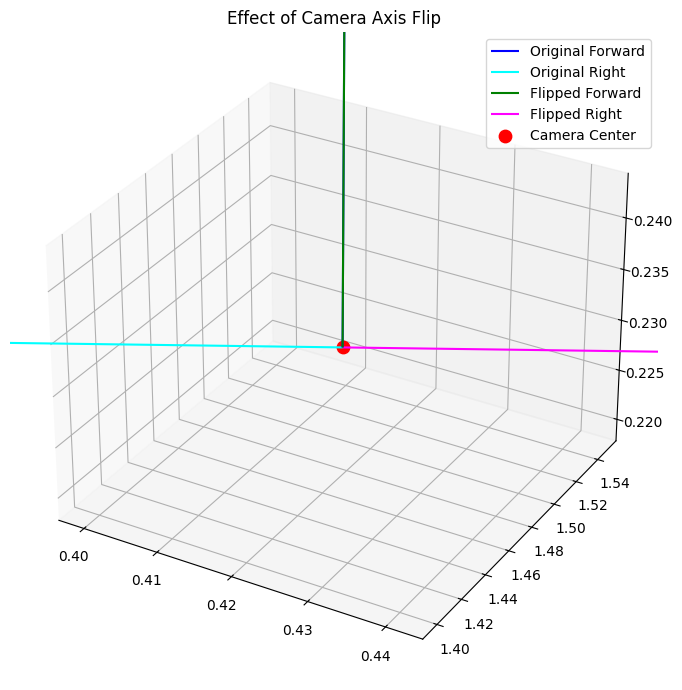

In [14]:
import matplotlib.pyplot as plt

# Camera axes before flip
cam_to_world = np.linalg.inv(T_raw)
cam_center = cam_to_world[:3, 3]
orig_forward = cam_to_world[:3, 2]
orig_right   = cam_to_world[:3, 0]
orig_up      = cam_to_world[:3, 1]

# Flipped axes
flip_forward = orig_forward.copy()
flip_right = orig_right.copy()
if orig_forward[0] < 0:
    flip_forward = -flip_forward
if orig_right[1] < 0:
    flip_right = -flip_right

# Plot
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

scale = 0.2 * np.linalg.norm(Pw.max(axis=0) - Pw.min(axis=0))

# Original axes
ax.quiver(*cam_center, *(orig_forward*scale), color='blue', label='Original Forward')
ax.quiver(*cam_center, *(orig_right*scale), color='cyan', label='Original Right')

# Flipped axes
ax.quiver(*cam_center, *(flip_forward*scale), color='green', label='Flipped Forward')
ax.quiver(*cam_center, *(flip_right*scale), color='magenta', label='Flipped Right')

ax.scatter(*cam_center, color='red', s=80, label='Camera Center')
ax.legend()
ax.set_title("Effect of Camera Axis Flip")
plt.tight_layout()
plt.show()

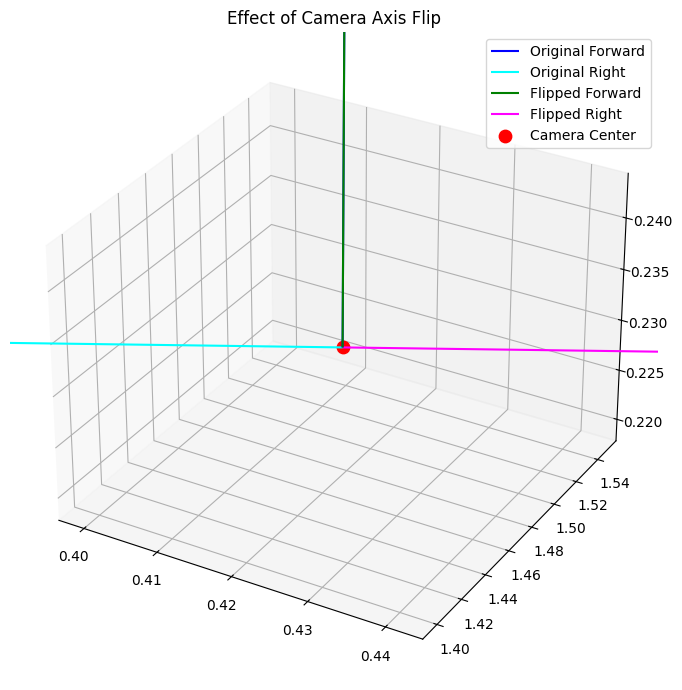

In [15]:
import matplotlib.pyplot as plt

# Camera axes before flip
cam_to_world = np.linalg.inv(T_raw)
cam_center = cam_to_world[:3, 3]
orig_forward = cam_to_world[:3, 2]
orig_right   = cam_to_world[:3, 0]
orig_up      = cam_to_world[:3, 1]

# Flipped axes
flip_forward = orig_forward.copy()
flip_right = orig_right.copy()
if orig_forward[0] < 0:
    flip_forward = -flip_forward
if orig_right[1] < 0:
    flip_right = -flip_right

# Plot
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

scale = 0.2 * np.linalg.norm(Pw.max(axis=0) - Pw.min(axis=0))

# Original axes
ax.quiver(*cam_center, *(orig_forward*scale), color='blue', label='Original Forward')
ax.quiver(*cam_center, *(orig_right*scale), color='cyan', label='Original Right')

# Flipped axes
ax.quiver(*cam_center, *(flip_forward*scale), color='green', label='Flipped Forward')
ax.quiver(*cam_center, *(flip_right*scale), color='magenta', label='Flipped Right')

ax.scatter(*cam_center, color='red', s=80, label='Camera Center')
ax.legend()
ax.set_title("Effect of Camera Axis Flip")
plt.tight_layout()
plt.show()

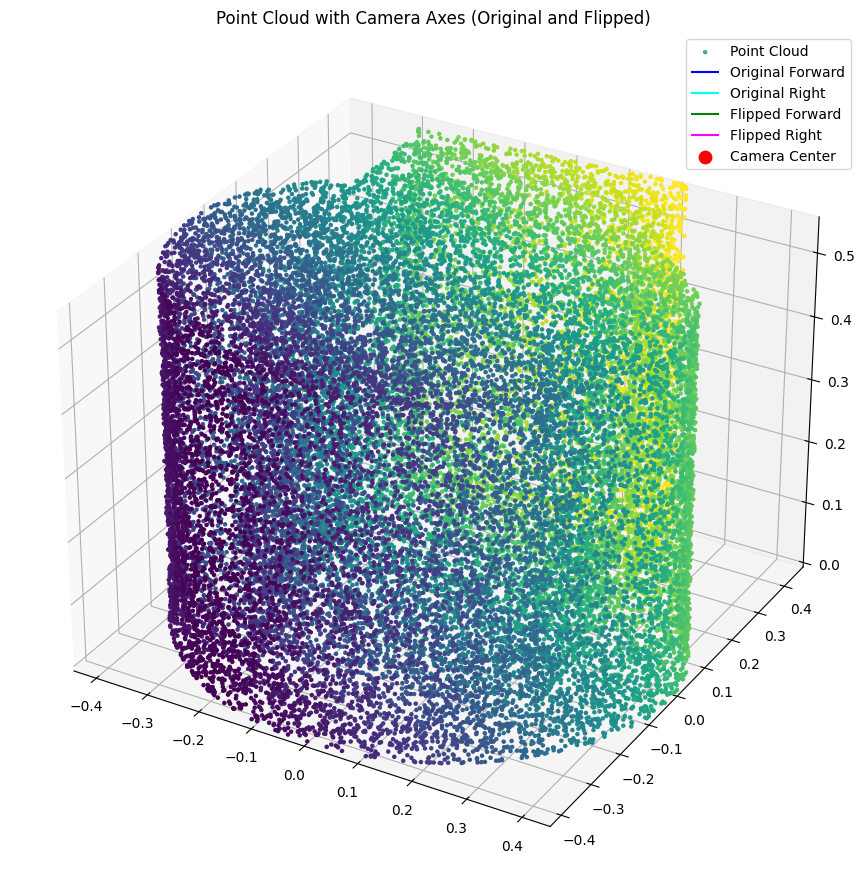

In [16]:
import matplotlib.pyplot as plt

# Camera axes before flip
cam_to_world = np.linalg.inv(T_raw)
cam_center = cam_to_world[:3, 3]
orig_forward = cam_to_world[:3, 2]
orig_right   = cam_to_world[:3, 0]
orig_up      = cam_to_world[:3, 1]

# Flipped axes
flip_forward = orig_forward.copy()
flip_right = orig_right.copy()
if orig_forward[0] < 0:
    flip_forward = -flip_forward
if orig_right[1] < 0:
    flip_right = -flip_right

# Plot point cloud and axes
fig = plt.figure(figsize=(10,9))
ax = fig.add_subplot(111, projection='3d')

# Downsample for speed if needed
N = Pw.shape[0]
take = min(N, 30000)
idx = np.random.choice(N, take, replace=False) if N > take else np.arange(N)
ax.scatter(Pw[idx,0], Pw[idx,1], Pw[idx,2], c=prob[idx], cmap='viridis', s=5, alpha=1.0, label='Point Cloud')

scale = 0.2 * np.linalg.norm(Pw.max(axis=0) - Pw.min(axis=0))

# Original axes
ax.quiver(*cam_center, *(orig_forward*scale), color='blue', label='Original Forward')
ax.quiver(*cam_center, *(orig_right*scale), color='cyan', label='Original Right')

# Flipped axes
ax.quiver(*cam_center, *(flip_forward*scale), color='green', label='Flipped Forward')
ax.quiver(*cam_center, *(flip_right*scale), color='magenta', label='Flipped Right')

ax.scatter(*cam_center, color='red', s=80, label='Camera Center')

# Set axis limits for better visibility
ax.set_xlim(Pw[:,0].min(), Pw[:,0].max())
ax.set_ylim(Pw[:,1].min(), Pw[:,1].max())
ax.set_zlim(Pw[:,2].min(), Pw[:,2].max())

ax.legend()
ax.set_title("Point Cloud with Camera Axes (Original and Flipped)")
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
from pathlib import Path

save_path = Path("object_pcd_with_prob.npz")

np.savez_compressed(
    save_path,
    points=Pw.astype(np.float32),
    probability=prob.astype(np.float32),
    colors=colors.astype(np.float32)
)

print(f"Saved to: {save_path.resolve()}")
print(f"Points shape: {Pw.shape}")

Saved to: C:\Users\Priyam Mishra\Desktop\UTN Thesis\UTN-ThesisResearch\notebook\object_pcd_with_prob.npz
Points shape: (1202688, 3)


In [18]:
import cv2
import numpy as np

nonuse_mask_path = r"C:\Users\Priyam Mishra\Desktop\UTN Thesis\UTN-ThesisResearch\Webots\controllers\tb4\first3dreco\non_usability_mask.png"  # <-- EDIT

nonuse = cv2.imread(nonuse_mask_path, cv2.IMREAD_GRAYSCALE)
if nonuse is None:
    raise FileNotFoundError(nonuse_mask_path)

# Ensure same size as RGB
if nonuse.shape[:2] != rgb.shape[:2]:
    nonuse = cv2.resize(nonuse, (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST)

# Binarize (adjust threshold if needed)
nonuse_bin = (nonuse > 127).astype(np.uint8)

print("nonuse_bin:", nonuse_bin.shape, "unique:", np.unique(nonuse_bin))

nonuse_bin: (720, 1280) unique: [0 1]


In [19]:
# points_world: (N,3) in world frame
# prob: (N,) probability for each point (same indexing as points_world)

u, v, depth = project_with_basis(Pw, K, w2c, FORWARD, RIGHT, UP)

H, W = rgb.shape[:2]

# Pixel indices
ui = np.round(u).astype(np.int32)
vi = np.round(v).astype(np.int32)

# Visibility / image bounds
valid = (depth > 1e-6) & (ui >= 0) & (ui < W) & (vi >= 0) & (vi < H)

# Points that land on non-usability mask
on_nonuse = np.zeros_like(valid, dtype=bool)
on_nonuse[valid] = (nonuse_bin[vi[valid], ui[valid]] == 1)

print("Total points:", len(Pw))
print("Valid projected:", int(valid.sum()))
print("On non-use mask:", int(on_nonuse.sum()))

Total points: 1202688
Valid projected: 1202688
On non-use mask: 934194


In [20]:
N = len(Pw)

# Start as usable (+1)
usability = np.ones(N, dtype=np.int8)   # +1 usable, -1 non-usable

idx = np.where(on_nonuse)[0]
if idx.size == 0:
    print("No points fall on non-usability mask. All points remain usable.")
else:
    # pixel id for each point on mask
    pix_id = vi[idx].astype(np.int64) * W + ui[idx].astype(np.int64)

    # Sort by pixel then by prob descending
    order = np.lexsort((-prob[idx], pix_id))  # primary: pix_id, secondary: -prob
    idx_sorted = idx[order]
    pix_sorted = pix_id[order]

    # Keep first occurrence per pixel (highest prob due to sorting)
    first = np.ones(idx_sorted.shape[0], dtype=bool)
    first[1:] = pix_sorted[1:] != pix_sorted[:-1]
    chosen_nonuse = idx_sorted[first]

    # Mark chosen as non-usable (-1)
    usability[chosen_nonuse] = -1

    print("Non-usable points assigned:", chosen_nonuse.size)
    print("Still usable points:", int((usability == 1).sum()))

Non-usable points assigned: 121532
Still usable points: 1081156


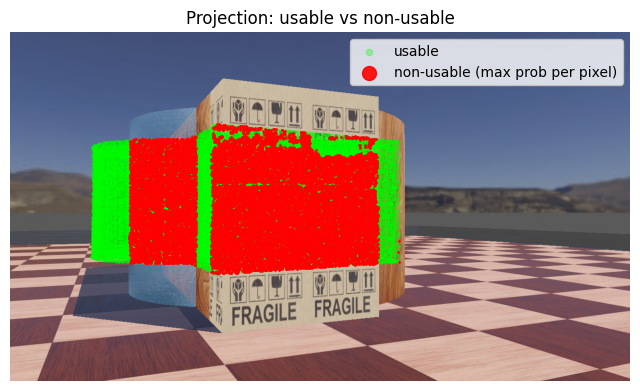

In [21]:
import matplotlib.pyplot as plt

# Downsample for plotting
take = 200000
all_valid = np.where(valid)[0]
if all_valid.size > take:
    plot_idx = np.random.choice(all_valid.size, take, replace=False)
    plot_idx = all_valid[plot_idx]
else:
    plot_idx = all_valid

nonuse_pts = plot_idx[usability[plot_idx] == -1]
use_pts    = plot_idx[usability[plot_idx] == 1]

plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.scatter(ui[use_pts],   vi[use_pts],   s=0.2, c="lime", alpha=0.3, label="usable")
plt.scatter(ui[nonuse_pts],vi[nonuse_pts],s=1.0, c="red",  alpha=0.9, label="non-usable (max prob per pixel)")
plt.title("Projection: usable vs non-usable")
plt.legend(markerscale=10)
plt.axis("off")
plt.show()

In [22]:
from pathlib import Path

out_dir = Path("outputs_usability_probability")
out_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    out_dir / "pcd1_with_prob_and_usability.npz",
    points=Pw.astype(np.float32),
    probability=prob.astype(np.float32),
    usability=usability.astype(np.int8),  # +1 usable, -1 non-usable
)

print("Saved:", out_dir / "pcd1_with_prob_and_usability.npz")

Saved: outputs_usability_probability\pcd1_with_prob_and_usability.npz


In [23]:
import numpy as np
from pathlib import Path

npz_path = Path("outputs_usability_probability/pcd1_with_prob_and_usability.npz")

data = np.load(npz_path)

Pw_npz = data["points"].astype(np.float32)
prob_npz   = data["probability"].astype(np.float32)
usability  = data["usability"].astype(np.int8)

print("Loaded:", npz_path.resolve())
print("points:", Pw_npz.shape)
print("prob:", prob_npz.shape)
print("usability:", usability.shape)
print("Unique usability values:", np.unique(usability))

Loaded: C:\Users\Priyam Mishra\Desktop\UTN Thesis\UTN-ThesisResearch\notebook\outputs_usability_probability\pcd1_with_prob_and_usability.npz
points: (1202688, 3)
prob: (1202688,)
usability: (1202688,)
Unique usability values: [-1  1]


In [24]:
import matplotlib.pyplot as plt
import numpy as np

def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    plot_radius = 0.5 * max([x_range, y_range, z_range])

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])


def plot_usability_3d(points, prob, usability, prob_thresh=0.6, max_points=250000):

    # Downsample for speed if needed
    N = len(points)
    if N > max_points:
        idx = np.random.choice(N, max_points, replace=False)
        pts = points[idx]
        pr  = prob[idx]
        us  = usability[idx]
    else:
        pts = points
        pr  = prob
        us  = usability

    # Masks
    high_prob = pr >= prob_thresh
    low_prob  = pr < prob_thresh

    usable_pts    = high_prob & (us == 1)
    nonusable_pts = high_prob & (us == -1)

    fig = plt.figure(figsize=(9,9))
    ax = fig.add_subplot(111, projection='3d')

    # Plot order: grey first (background)
    ax.scatter(pts[low_prob,0], pts[low_prob,1], pts[low_prob,2],
               c='lightgrey', s=0.3, alpha=0.3, label='Low prob (grey)')

    ax.scatter(pts[usable_pts,0], pts[usable_pts,1], pts[usable_pts,2],
               c='lime', s=0.6, alpha=0.8, label='Usable (high prob)')

    ax.scatter(pts[nonusable_pts,0], pts[nonusable_pts,1], pts[nonusable_pts,2],
               c='red', s=1.2, alpha=1.0, label='Non-usable (high prob)')

    ax.set_title(f"3D Usability Visualization (prob >= {prob_thresh})")
    ax.legend(loc='upper right')
    ax.view_init(elev=20, azim=35)
    set_axes_equal(ax)
    plt.tight_layout()
    plt.show()

    print("High-prob usable:", usable_pts.sum())
    print("High-prob non-usable:", nonusable_pts.sum())
    print("Low-prob (grey):", low_prob.sum())

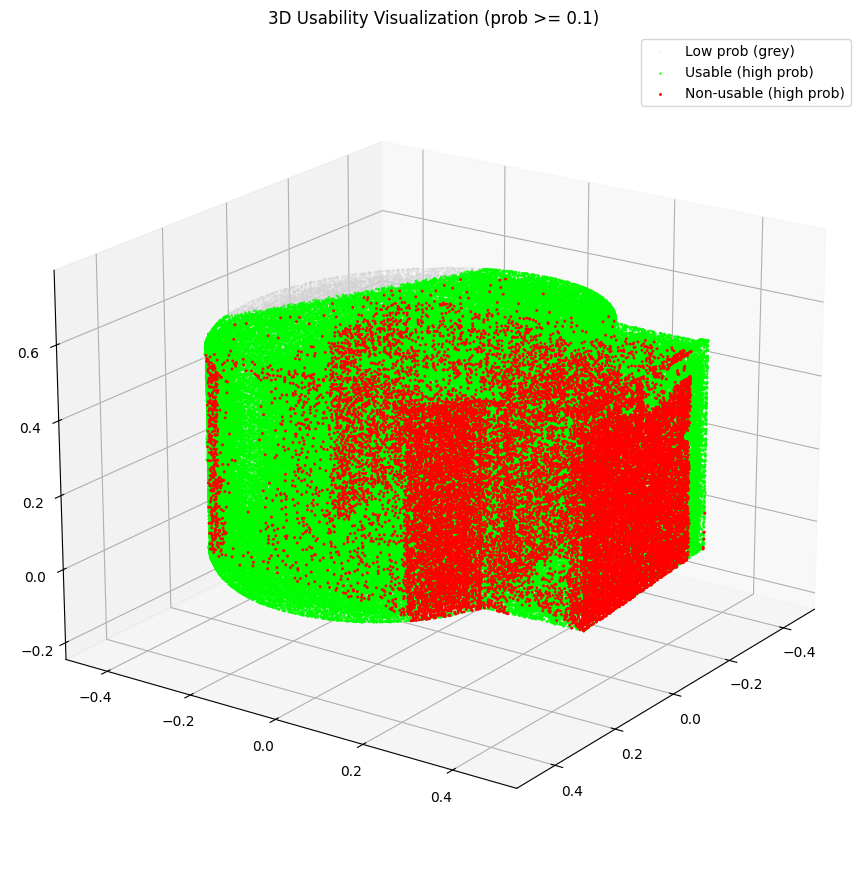

High-prob usable: 196706
High-prob non-usable: 25103
Low-prob (grey): 28191


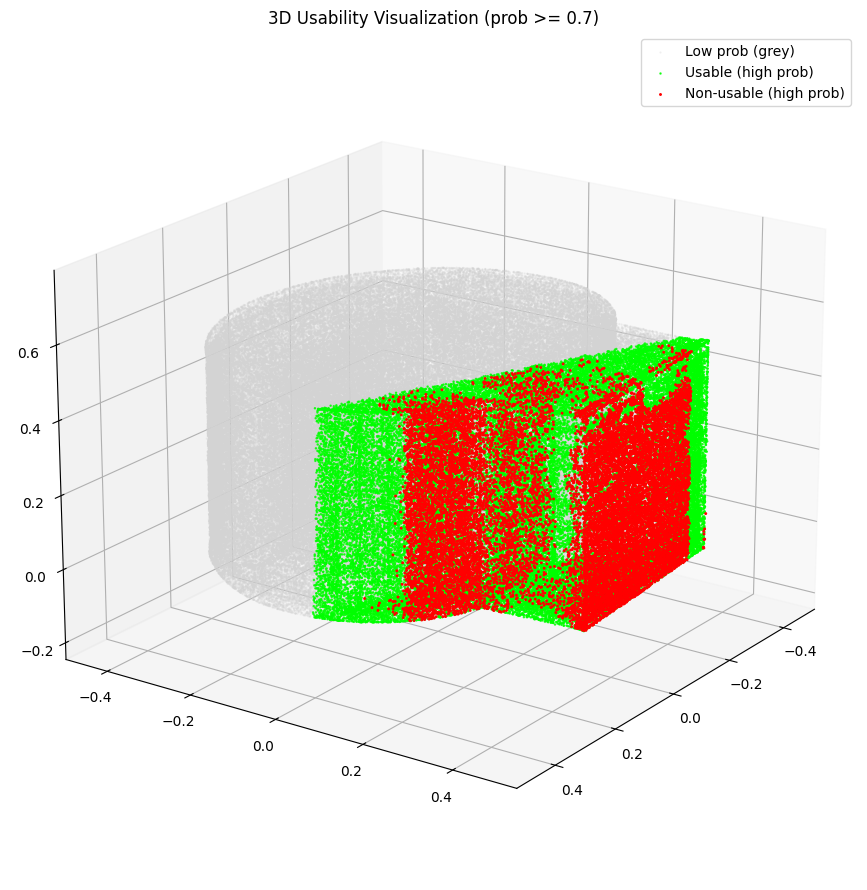

High-prob usable: 47896
High-prob non-usable: 18045
Low-prob (grey): 184059


In [25]:
plot_usability_3d(Pw_npz, prob_npz, usability, prob_thresh=0.1)
plot_usability_3d(Pw_npz, prob_npz, usability, prob_thresh=0.7)

### Assigning clip features also to points

In [26]:
import numpy as np

idx_on = np.asarray(idx_on, dtype=np.int64)

# Your probability for ALL points
prob_all = np.asarray(prob, dtype=np.float32)   # change name if yours is different

prob_thr = 0.35   # try 0.3 / 0.4

prob_on = prob_all[idx_on]
keep = prob_on >= prob_thr

idx_keep  = idx_on[keep]
prob_keep = prob_on[keep]

print("idx_on:", len(idx_on))
print(f"selected prob >= {prob_thr}:", len(idx_keep))
print("prob_keep range:", (float(prob_keep.min()), float(prob_keep.max())) if len(prob_keep) else None)

idx_on: 149521
selected prob >= 0.35: 135732
prob_keep range: (0.35002923011779785, 1.0)


In [27]:
import numpy as np

idx_vis = np.asarray(idx_vis, dtype=np.int64)
uu_vis  = np.asarray(uu_vis, dtype=np.float32)
vv_vis  = np.asarray(vv_vis, dtype=np.float32)

# Build index -> position lookup
pos_in_vis = {int(p): i for i, p in enumerate(idx_vis)}

# idx_keep should be a subset of idx_vis if idx_on came from idx_vis
pos = np.array([pos_in_vis[int(p)] for p in idx_keep], dtype=np.int64)

u_keep = uu_vis[pos]
v_keep = vv_vis[pos]

print("u_keep/v_keep:", u_keep.shape, v_keep.shape)

u_keep/v_keep: (135732,) (135732,)


In [28]:
import torch
import open_clip
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model_name = "ViT-B-32"
clip_pretrained = "laion2b_s34b_b79k"

model, _, preprocess = open_clip.create_model_and_transforms(
    clip_model_name, pretrained=clip_pretrained
)
model = model.to(device).eval()

rgb_np = rgb
if rgb_np.dtype != np.uint8:
    rgb_np = np.clip(rgb_np * 255.0, 0, 255).astype(np.uint8)

img_pil = Image.fromarray(rgb_np)
H, W = rgb_np.shape[:2]

patch_px  = 28
stride_px = 28
batch_size = 64

xs = np.arange(0, W - patch_px + 1, stride_px, dtype=np.int32)
ys = np.arange(0, H - patch_px + 1, stride_px, dtype=np.int32)

x_centers = xs + patch_px * 0.5
y_centers = ys + patch_px * 0.5

print("Patch grid:", len(xs), "x", len(ys), "=", len(xs)*len(ys))

patch_feats = []
with torch.no_grad():
    batch = []
    for y in ys:
        for x in xs:
            crop = img_pil.crop((int(x), int(y), int(x + patch_px), int(y + patch_px)))
            batch.append(preprocess(crop))
            if len(batch) == batch_size:
                inp = torch.stack(batch).to(device)
                feat = model.encode_image(inp).float()
                feat = feat / (feat.norm(dim=-1, keepdim=True) + 1e-12)
                patch_feats.append(feat.cpu())
                batch = []
    if batch:
        inp = torch.stack(batch).to(device)
        feat = model.encode_image(inp).float()
        feat = feat / (feat.norm(dim=-1, keepdim=True) + 1e-12)
        patch_feats.append(feat.cpu())

patch_feats = torch.cat(patch_feats, dim=0)  # (Npatch, D)
print("patch_feats:", tuple(patch_feats.shape))

Patch grid: 45 x 25 = 1125
patch_feats: (1125, 512)


In [29]:
import numpy as np
import torch

if len(idx_keep) == 0:
    print("No points selected. Lower prob_thr.")
else:
    # nearest patch center (searchsorted + neighbor refinement)
    gx = np.clip(np.searchsorted(x_centers, u_keep) - 1, 0, len(xs) - 1)
    gx2 = np.clip(gx + 1, 0, len(xs) - 1)
    gx = np.where(np.abs(x_centers[gx2] - u_keep) < np.abs(x_centers[gx] - u_keep), gx2, gx)

    gy = np.clip(np.searchsorted(y_centers, v_keep) - 1, 0, len(ys) - 1)
    gy2 = np.clip(gy + 1, 0, len(ys) - 1)
    gy = np.where(np.abs(y_centers[gy2] - v_keep) < np.abs(y_centers[gy] - v_keep), gy2, gy)

    patch_idx = (gy * len(xs) + gx).astype(np.int64)
    clip_keep = patch_feats[torch.from_numpy(patch_idx)]  # (K, D)

    out_pt = "clip_sparse_probthr1.pt"
    torch.save(
        {
            "idx_keep": torch.from_numpy(idx_keep).long(),     # indices into full point cloud
            "u_keep": torch.from_numpy(u_keep).float(),
            "v_keep": torch.from_numpy(v_keep).float(),
            "prob_keep": torch.from_numpy(prob_keep).float(),
            "clip_keep": clip_keep.contiguous().float(),       # (K,D)
            "meta": {
                "prob_thr": float(prob_thr),
                "patch_px": int(patch_px),
                "stride_px": int(stride_px),
                "clip_model": clip_model_name,
                "clip_pretrained": clip_pretrained,
            },
        },
        out_pt,
    )

    print("Assigned CLIP to:", len(idx_keep), "points | saved:", out_pt, "| clip dim:", clip_keep.shape[1])

Assigned CLIP to: 135732 points | saved: clip_sparse_probthr1.pt | clip dim: 512


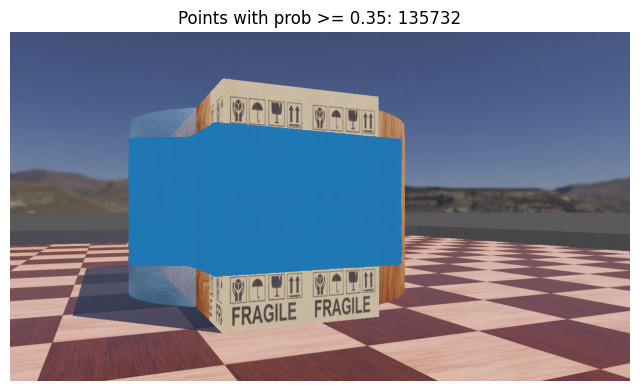

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.scatter(u_keep, v_keep, s=3, alpha=0.8)
plt.title(f"Points with prob >= {prob_thr}: {len(idx_keep)}")
plt.axis("off")
plt.show()

In [31]:
import numpy as np
import torch

# ---------- REQUIRED GLOBAL ARRAYS ----------
# points_world: (N,3)
# probability: (N,)
# usability: (N,)  with values {+1,-1} (or 0 for unknown)
# rgb optional (not saved)
#
# idx_keep + clip_keep are sparse (K,) and (K,D) for prob-threshold selected points

P = np.asarray(Pw, dtype=np.float32)
N = P.shape[0]

prob_all = np.asarray(prob, dtype=np.float32)
assert prob_all.shape[0] == N, f"probability length {prob_all.shape[0]} != N {N}"

use_all = np.asarray(usability, dtype=np.int8)
assert use_all.shape[0] == N, f"usability length {use_all.shape[0]} != N {N}"

# Optional colors if you have them
colors_all = None
if "colors" in globals() and globals()["colors"] is not None:
    colors_all = np.asarray(colors, dtype=np.float32)
    if colors_all.shape[0] != N:
        print("Warning: colors length mismatch; skipping colors.")
        colors_all = None

# ---------- SPARSE CLIP (selected points) ----------
# idx_keep: (K,) indices into [0..N-1]
# clip_keep: (K,D)
idx_keep_np = np.asarray(idx_keep, dtype=np.int64)
prob_keep_np = np.asarray(prob_keep, dtype=np.float32)

# clip_keep might be torch tensor
clip_keep_t = clip_keep if isinstance(clip_keep, torch.Tensor) else torch.from_numpy(np.asarray(clip_keep))
clip_keep_t = clip_keep_t.contiguous().float()

assert idx_keep_np.ndim == 1, "idx_keep must be 1D"
assert clip_keep_t.shape[0] == idx_keep_np.shape[0], "clip_keep rows must match idx_keep length"

# ---------- 1) MASTER SAVE (single file, index-safe) ----------
# Everything here is full-length and aligned by point index i.
master_path = "pcd_master_with_prob_use_1angle.npz"
save_dict = {
    "points_world": P,            # (N,3)
    "probability": prob_all,      # (N,)
    "usability": use_all,         # (N,)
}
if colors_all is not None:
    save_dict["colors"] = colors_all

# store metadata too
save_dict["meta_prob_thr"] = np.array([prob_thr], dtype=np.float32) if "prob_thr" in globals() else np.array([-1], np.float32)

np.savez_compressed(master_path, **save_dict)
print("Saved MASTER:", master_path, "| N =", N)

# ---------- 2) SPARSE CLIP SAVE (keeps file small but index-consistent) ----------
# Still safe because idx_keep indexes into the same master points.
clip_path = "pcd_clip_sparse_probthr_1angle.pt"
torch.save(
    {
        "idx_keep": torch.from_numpy(idx_keep_np).long(),      # indices into master points
        "prob_keep": torch.from_numpy(prob_keep_np).float(),   # convenience
        "clip_keep": clip_keep_t,                              # (K,D)
        "meta": {
            "prob_thr": float(prob_thr) if "prob_thr" in globals() else None,
            "patch_px": int(patch_px) if "patch_px" in globals() else None,
            "stride_px": int(stride_px) if "stride_px" in globals() else None,
            "clip_model": clip_model_name if "clip_model_name" in globals() else None,
            "clip_pretrained": clip_pretrained if "clip_pretrained" in globals() else None,
        },
    },
    clip_path,
)
print("Saved SPARSE CLIP:", clip_path, "| K =", len(idx_keep_np), "| D =", int(clip_keep_t.shape[1]))

# ---------- 3) OPTIONAL: sanity checks ----------
# verify indexing stable
if len(idx_keep_np):
    i0 = idx_keep_np[0]
    print("Sanity sample index:", i0,
          "| point:", P[i0],
          "| prob:", prob_all[i0],
          "| usability:", use_all[i0])

Saved MASTER: pcd_master_with_prob_use_1angle.npz | N = 1202688
Saved SPARSE CLIP: pcd_clip_sparse_probthr_1angle.pt | K = 135732 | D = 512
Sanity sample index: 235304 | point: [0.20684673 0.4722565  0.5549454 ] | prob: 1.0 | usability: -1


: 